# MIPT Tutorial - Measurement-Induced Phase Transition

This tutorial demonstrates the **Measurement-Induced Phase Transition (MIPT)** in a 1D quantum circuit with random unitary gates and projective measurements.

## What is MIPT?

The MIPT arises from a competition between two processes:

1. **Unitary evolution** (Haar random gates): Creates entanglement between qubits
2. **Projective measurements** (Z-basis): Destroys entanglement locally

Depending on the measurement rate, the system exhibits two distinct phases:

- **Volume-law phase** (p < p_c ≈ 0.16): Entanglement entropy scales with system size S ~ L
- **Area-law phase** (p > p_c ≈ 0.16): Entanglement entropy remains constant S ~ const
- **Critical point** (p ≈ p_c): Logarithmic scaling S ~ log(L)


## Setup

First, activate the project environment and import QuantumCircuitsMPS:

In [1]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Statistics
using Plots
using ProgressMeter
using Luxor

  Activating project at `~/personal/QuantumCircuitsMPS.jl`


## Section 1: Setup and Parameters

Define the system parameters for the MIPT simulation:

In [2]:
# Define system parameters
const L = 8                   # System size (number of qubits)
const bc = :periodic           # Boundary conditions
const n_steps = L             # Total timesteps for simulation (passed to simulate!(n_steps=n_steps))
const p = 0.5                 # Measurement probability (near critical p_c ≈ 0.16)
const cut = L ÷ 2              # Entanglement cut position

println("Parameters:")
println("  L = $L (system size)")
println("  bc = $bc (boundary conditions)")
println("  n_steps = $n_steps (circuit timesteps)")
println("  p = $p (measurement probability)")
println("  cut = $cut (entanglement cut position)")

Parameters:
  L = 8 (system size)
  bc = periodic (boundary conditions)
  n_steps = 8 (circuit timesteps)
  p = 0.5 (measurement probability)
  cut = 4 (entanglement cut position)


## Section 2: Building the MIPT Circuit

The circuit implements the standard MIPT protocol with Bricklayer unitary gates followed by stochastic measurements.


In [3]:
# Build circuit (one full MIPT cycle per do-block execution: even+measure+odd+measure)
circuit = Circuit(L=L, bc=bc, p=p) do c
    apply!(c, HaarRandom(), Bricklayer(:even))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
    apply!(c, HaarRandom(), Bricklayer(:odd))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
end

println("Circuit built successfully")
println("Circuit parameters: L=$(circuit.L), bc=$(circuit.bc)")
println("System size: $(circuit.L) qubits")
println("Boundary conditions: $(circuit.bc)")

Circuit built successfully
Circuit parameters: L=8, bc=periodic
System size: 8 qubits
Boundary conditions: periodic
Circuit parameters: L=8, bc=periodic
System size: 8 qubits
Boundary conditions: periodic


### Circuit Visualization

Visualize the circuit structure to inspect the gate layout before running the simulation:

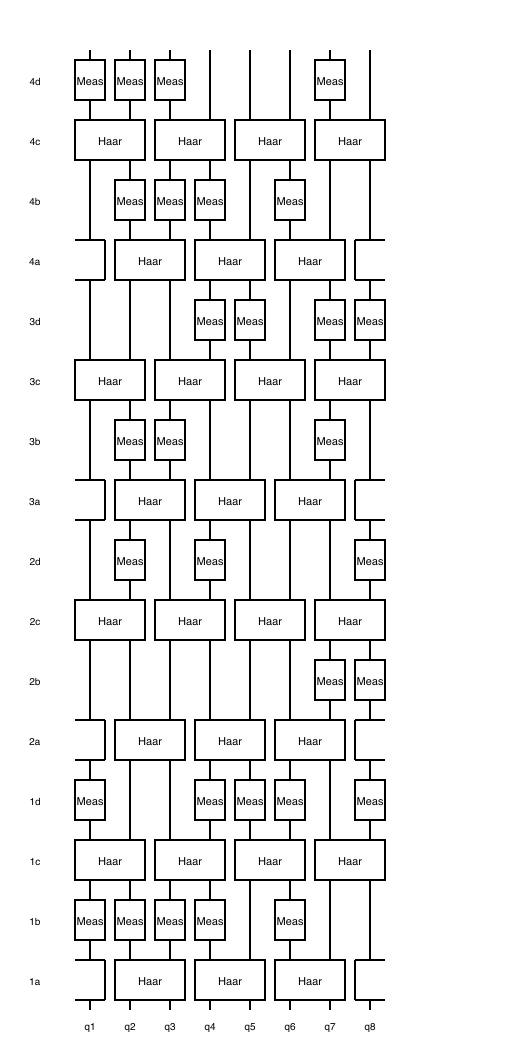

In [4]:
plot_circuit(circuit; gates_spacetime=0, n_steps=4)

## Section 3: Simulation with Entanglement Tracking

We track the **entanglement entropy** at the central cut (position L÷2) to monitor the competition between:
- Unitary entanglement generation
- Measurement-induced disentanglement

The `EntanglementEntropy` observable computes the von Neumann entropy across a bipartite cut:

$$S = -\sum_i \lambda_i^2 \log(\lambda_i^2)$$

where $\lambda_i$ are the Schmidt coefficients from the SVD of the MPS bond.

In [5]:
# Create simulation state with RNG registry
state = SimulationState(
    L=L,
    bc=bc,
    maxdim=64,
    rng=RNGRegistry(gates_spacetime=0, born_measurement=0, gates_realization=2)
)

# Initialize to product state |0⟩⊗L
initialize!(state, ProductState(binary_int=0))

# Track entanglement entropy at the central cut
track!(state, :entropy => EntanglementEntropy(; cut=cut))

# Run simulation: execute circuit n_steps times (n_steps=n_steps)
simulate!(circuit, state; n_steps=n_steps, record_when=:every_step)

# Extract entropy values from state
entropy_vals = state.observables[:entropy]

println("✓ Simulation complete")
println("  Recorded $(length(entropy_vals)) entropy values")
println()

✓ Simulation complete
  Recorded 8 entropy values

  Recorded 8 entropy values



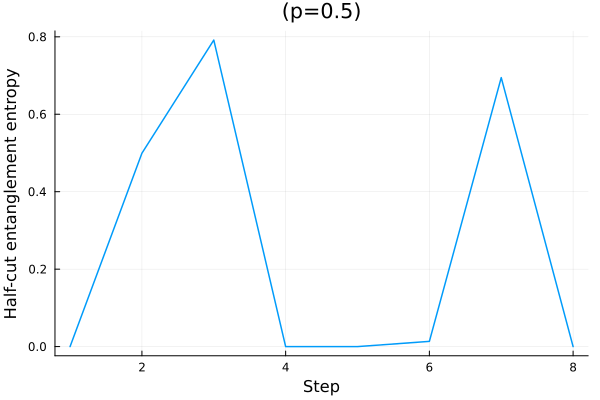

In [6]:
plot(entropy_vals, xlabel="Step", ylabel="Half-cut entanglement entropy", title="(p=$p)",
     legend=false, lw=1.5)

## Section 4: Steady-State Entanglement Entropy

Sweep `p` to compute the half-cut entanglement entropy as a function of measurement probability for multiple system sizes.

Each point is averaged over `ensemble_size` random seeds.

In [9]:
function run_mipt(; L, p, seed, bc=:periodic, n_steps=2*L, maxdim=2^20)
    circuit = Circuit(L=L, bc=bc, p=p) do c
        apply!(c, HaarRandom(), Bricklayer(:even))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
        apply!(c, HaarRandom(), Bricklayer(:odd))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
    end

    state = SimulationState(L=L, bc=bc, maxdim=maxdim,cutoff = 1e-10,
        # non-overlapping streams across trajectories
        rng=RNGRegistry(gates_spacetime=3*(seed-1)+1, born_measurement=3*(seed-1)+2, gates_realization=3*(seed-1)+3))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    simulate!(circuit, state; n_steps=n_steps, record_when=:final_only)
    return state.observables[:entropy][end]
end

run_mipt (generic function with 1 method)

In [10]:
# Sweep parameters
L_list = [6, 8, 10, 12, ]
# p_list = 0.1:0.1:0.9 |> collect
p_list = [0,0.1,.2,.3,.4,.5]
ensemble_size = 25  # reduced for quick notebook execution (recommended: 2000)

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_mipt(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
S_raw = reshape(raw, ns, np, nL)
S_mean = dropdims(mean(S_raw, dims=1), dims=1)
S_sem  = dropdims(std(S_raw, dims=1), dims=1) ./ sqrt(size(S_raw, 1))

println("Done!")

Running 600 configs on 4 threads...


Progress: 100%|█████████████████████████████████████████| Time: 0:01:16


 76.118275 seconds (1.09 G allocations: 273.684 GiB, 14.55% gc time, 50 lock conflicts, 5.38% compilation time)
Done!



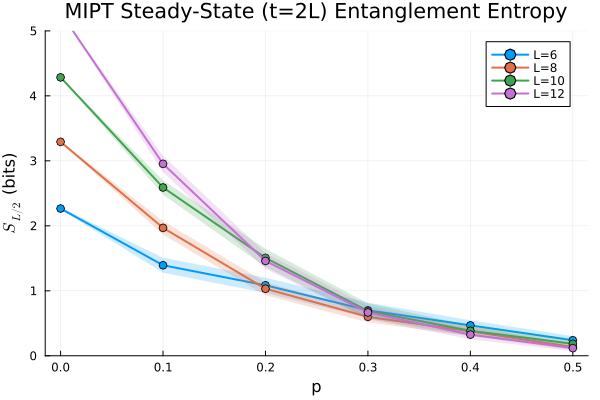

In [11]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$ (bits)", title=raw"MIPT Steady-State (t=2L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4, ylims=(0,5))
end
p_fig

## Section 5: SRN Boundary-Eligibility Protocol (Skinner–Ruhman–Nahum)

Skinner, Ruhman & Nahum, *PRX* **9**, 031009 (2019) [arXiv:1808.05953] use **open
boundary conditions (OBC)** with a specific measurement-eligibility rule: after
the even-bond Haar layer, only the **bulk** sites (2 through L-1) get a
measurement coin, since the edge sites (1 and L) did not just participate in a
fresh bond in that sublayer under OBC. After the odd-bond Haar layer, **every**
site gets a measurement coin. This "boundary eligibility" convention avoids the
$L \bmod 4$ parity artifact noted above (which comes from PBC's folded-basis
cut convention), and lets us reproduce their Fig. 13(a) volume-law/area-law
phase diagram quantitatively.

`run_mipt_srn` below builds this protocol as **one** `Circuit` with **two**
`record!(c)` markers (no manual `record!(state)` calls, no workaround scripts):

- Half-step A: `Bricklayer(:even)` Haar layer → `Measure(:Z)` with probability
  `p` on `EachSite(2:L-1)` (bulk-only) → `record!(c)`
- Half-step B: `Bricklayer(:odd)` Haar layer → `Measure(:Z)` with probability
  `p` on `AllSites()` → `record!(c)`
- `simulate!(circuit, state; n_steps=n_periods, record_when=:marks)` fires
  exactly at the two markers per period, deterministically.
- The half-cut bond $(L/2, L/2+1)$ is refreshed by the `:even` sublayer when
  $L/2$ is even and by the `:odd` sublayer when $L/2$ is odd, so we take the
  "fresh" snapshot (half-step A's record or half-step B's record,
  respectively) and average over the **last 4 periods** (steady state).

In [12]:
function run_mipt_srn(; L, p, seed, n_periods=4L, maxdim=2^20, cutoff=1e-10)
    iseven(L) || throw(ArgumentError("run_mipt_srn requires even L (got L=$L)"))

    circuit = Circuit(L=L, bc=:open, p=p) do c
        # Half-step A: even Haar bricklayer (bulk-only under OBC), then
        # bulk-only measurement coins (EachSite(2:L-1)).
        apply!(c, HaarRandom(), Bricklayer(:even))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=EachSite(2:L-1))
        ])
        record!(c)

        # Half-step B: odd Haar bricklayer (touches all sites under OBC),
        # then all-site measurement coins (AllSites()).
        apply!(c, HaarRandom(), Bricklayer(:odd))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
        record!(c)
    end

    state = SimulationState(L=L, bc=:open, maxdim=maxdim, cutoff=cutoff,
        rng=RNGRegistry(gates_spacetime=3*(seed-1)+1, born_measurement=3*(seed-1)+2, gates_realization=3*(seed-1)+3))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    # record_when=:marks fires EXACTLY at the two record!(c) markers above.
    simulate!(circuit, state; n_steps=n_periods, record_when=:marks)

    records = state.observables[:entropy]  # length 2*n_periods: [A1,B1,A2,B2,...]
    fresh_phase = iseven(L ÷ 2) ? 1 : 2     # 1 = half-step A (:even), 2 = half-step B (:odd)
    tail = records[end-7:end]               # last 4 periods = last 8 records
    return fresh_phase == 1 ? mean(tail[1:2:end]) : mean(tail[2:2:end])
end


run_mipt_srn (generic function with 1 method)

In [13]:
# Sweep parameters
L_list = [6, 8, 10, 12,]
# p_list = 0.1:0.1:0.9 |> collect
p_list = [0,0.1,.2,.3,.4,.5]
ensemble_size = 25  # reduced for quick notebook execution (recommended: 2000)

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_mipt_srn(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
S_raw = reshape(raw, ns, np, nL)
S_mean = dropdims(mean(S_raw, dims=1), dims=1)
S_sem  = dropdims(std(S_raw, dims=1), dims=1) ./ sqrt(size(S_raw, 1))

println("Done!")

Running 600 configs on 4 threads...


Progress:   0%|▏                                        |  ETA: 0:01:34

Progress: 100%|█████████████████████████████████████████| Time: 0:01:58

118.820219 seconds (1.91 G allocations: 463.038 GiB, 13.76% gc time, 49 lock conflicts, 0.74% compilation time)
Done!


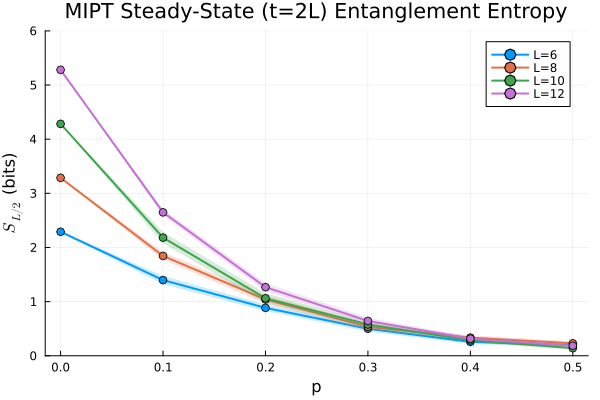

In [14]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$ (bits)", title=raw"MIPT Steady-State (t=2L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4, ylims=(0,6))
end
p_fig

## Section 6: State Vector Backend Comparison

The state-vector backend stores the exact dense wavefunction (no MPS truncation). Since the `Circuit` object is backend-independent — it stores gate objects symbolically, never matrices — running the *same* circuit with the *same* RNG seed on both backends produces the *same* physics. Below, we re-run the Section 3 MIPT circuit on both backends and confirm the underlying quantum states match to numerical precision.

**Entanglement entropy under periodic BC**: the MPS backend's ring-to-chain fold now starts at the middle-aligned site `pbc_fold_start = L÷4+1` (the new default), so the RAM half-cut used internally by the MPS backend coincides exactly with the physical bipartition {1..L/2} vs {L/2+1..L} that the state-vector backend has always used. This means `EntanglementEntropy(cut=L÷2)` can be compared **directly** between backends — no fidelity workaround or separate-cut-convention caveat is needed anymore.

In [7]:
# MPS backend
mps_state = SimulationState(L=L, bc=bc, maxdim=64,
    rng=RNGRegistry(gates_spacetime=0, born_measurement=0, gates_realization=2))
initialize!(mps_state, ProductState(binary_int=0))
track!(mps_state, :entropy => EntanglementEntropy(; cut=cut))
simulate!(circuit, mps_state; n_steps=n_steps, record_when=:every_step)

# State Vector backend (exact, no truncation)
sv_state = SimulationState(L=L, bc=bc, backend=:statevector,
    rng=RNGRegistry(gates_spacetime=0, born_measurement=0, gates_realization=2))
initialize!(sv_state, ProductState(binary_int=0))
track!(sv_state, :entropy => EntanglementEntropy(; cut=cut))
simulate!(circuit, sv_state; n_steps=n_steps, record_when=:every_step)

# Direct entropy comparison — same cut, same physical bipartition on both backends
S_mps = mps_state.observables[:entropy]
S_sv = sv_state.observables[:entropy]
max_entropy_error = maximum(abs.(S_mps .- S_sv))

println("MPS and SV simulations complete.")
println("Max entropy error (MPS vs SV): ", max_entropy_error)

MPS and SV simulations complete.
Max entropy error (MPS vs SV): 2.3314683517128287e-15


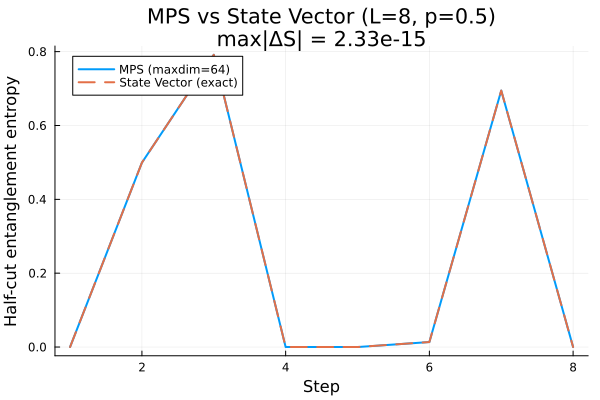

In [8]:
# Overlay both backends' entropy trajectories — should be visually indistinguishable
plot(S_mps, label="MPS (maxdim=64)", lw=2, xlabel="Step",
     ylabel="Half-cut entanglement entropy",
     title="MPS vs State Vector (L=$L, p=$p)\nmax|ΔS| = $(round(max_entropy_error, sigdigits=3))")
plot!(S_sv, label="State Vector (exact)", lw=2, ls=:dash)

## Section 7: Clifford Backend — MIPT with Stabilizer Formalism

The **Clifford backend** (`backend=:clifford`) uses the stabilizer formalism (via [QuantumClifford.jl](https://github.com/QuantumSavory/QuantumClifford.jl)) to simulate circuits composed entirely of Clifford gates. Instead of storing a dense state vector ($2^L$ amplitudes) or an MPS (bond-dimension-limited), the stabilizer representation tracks $L$ stabilizer generators — an $O(L^2)$ data structure updated in $O(L)$–$O(L^2)$ time per gate.

**Key advantage**: Polynomial scaling enables simulation of hundreds or thousands of qubits, far beyond the state-vector backend's practical $L \lesssim 25$ limit and the MPS backend's $\chi$-limited fidelity at large entanglement.

**Constraint**: Only Clifford gates are supported — `RandomClifford()`, `Hadamard()`, `PauliX/Y/Z()`, `PhaseGate()`, `CNOT()`, `CZ()`, `SWAP()`. Non-Clifford gates (e.g. `HaarRandom()`, `Rx/Ry/Rz(θ)`) are rejected with an informative error.

Below, we demonstrate: (1) a `p`-sweep showing the entanglement phase transition, (2) exact cross-validation against the state-vector backend at small $L$, and (3) a large-$L$ simulation at $L=100$ — a system size infeasible for dense state vectors.

In [ ]:
# Clifford MIPT: same structure as Section 4's run_mipt(), but with RandomClifford() + backend=:clifford
function run_mipt_clifford(; L, p, seed, bc=:periodic, n_steps=2*L)
    circuit = Circuit(L=L, bc=bc, p=p) do c
        apply!(c, RandomClifford(), Bricklayer(:even))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
        apply!(c, RandomClifford(), Bricklayer(:odd))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
    end

    state = SimulationState(L=L, bc=bc, backend=:clifford,
        rng=RNGRegistry(gates_spacetime=3*(seed-1)+1, born_measurement=3*(seed-1)+2, gates_realization=3*(seed-1)+3))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    simulate!(circuit, state; n_steps=n_steps, record_when=:final_only)
    return state.observables[:entropy][end]
end

In [ ]:
# Sweep parameters (matching Section 4's convention)
L_list_cliff = [8, 12, 16, 20]
p_list_cliff = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
ensemble_size_cliff = 25  # reduced for quick notebook execution

configs_cliff = [(L=L, p=p, seed=s) for L in L_list_cliff for p in p_list_cliff for s in 1:ensemble_size_cliff]
raw_cliff = Vector{Float64}(undef, length(configs_cliff))

println("Running $(length(configs_cliff)) Clifford MIPT configs...")
@time Threads.@threads for i in eachindex(configs_cliff)
    c = configs_cliff[i]
    raw_cliff[i] = run_mipt_clifford(L=c.L, p=c.p, seed=c.seed)
end

ns_c, np_c, nL_c = ensemble_size_cliff, length(p_list_cliff), length(L_list_cliff)
S_raw_cliff = reshape(raw_cliff, ns_c, np_c, nL_c)
S_mean_cliff = dropdims(mean(S_raw_cliff, dims=1), dims=1)
S_sem_cliff  = dropdims(std(S_raw_cliff, dims=1), dims=1) ./ sqrt(ns_c)
println("Done!")

In [ ]:
p_cliff_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$ (bits)",
    title="Clifford MIPT: Steady-State Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list_cliff)
    plot!(p_cliff_fig, p_list_cliff, S_mean_cliff[:, iL], ribbon=S_sem_cliff[:, iL],
          fillalpha=0.2, label="L=$L", lw=2, marker=:o, ms=4)
end
p_cliff_fig

### Cross-Comparison: Clifford vs State Vector ($L=8$)

To validate the Clifford backend, we run the **exact same** Clifford circuit on both `backend=:clifford` and `backend=:statevector` with **identical RNG seeds**. The state-vector backend stores the full $2^L$-dimensional wavefunction and computes entropy via SVD — an exact, independent reference.

Both entropy trajectories should overlap perfectly (up to floating-point precision), confirming that the stabilizer-based entropy calculation agrees with the dense wavefunction approach.

In [ ]:
# Build a Clifford MIPT circuit for L=8
L_cmp = 8
bc_cmp = :periodic
p_cmp = 0.1
n_steps_cmp = L_cmp
cut_cmp = L_cmp ÷ 2

circuit_cmp = Circuit(L=L_cmp, bc=bc_cmp, p=p_cmp) do c
    apply!(c, RandomClifford(), Bricklayer(:even))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
    apply!(c, RandomClifford(), Bricklayer(:odd))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
end

# Clifford backend
cliff_state = SimulationState(L=L_cmp, bc=bc_cmp, backend=:clifford,
    rng=RNGRegistry(gates_spacetime=42, born_measurement=1, gates_realization=2))
initialize!(cliff_state, ProductState(binary_int=0))
track!(cliff_state, :entropy => EntanglementEntropy(; cut=cut_cmp))
simulate!(circuit_cmp, cliff_state; n_steps=n_steps_cmp, record_when=:every_step)

# State Vector backend (exact reference)
sv_state_cmp = SimulationState(L=L_cmp, bc=bc_cmp, backend=:statevector,
    rng=RNGRegistry(gates_spacetime=42, born_measurement=1, gates_realization=2))
initialize!(sv_state_cmp, ProductState(binary_int=0))
track!(sv_state_cmp, :entropy => EntanglementEntropy(; cut=cut_cmp))
simulate!(circuit_cmp, sv_state_cmp; n_steps=n_steps_cmp, record_when=:every_step)

# Compare
S_cliff_cmp = cliff_state.observables[:entropy]
S_sv_cmp = sv_state_cmp.observables[:entropy]
max_entropy_err = maximum(abs.(S_cliff_cmp .- S_sv_cmp))

println("Clifford entropy: ", S_cliff_cmp)
println("SV entropy:       ", [round(s, digits=12) for s in S_sv_cmp])
println("Max |S_cliff - S_sv| = ", max_entropy_err)

In [ ]:
plot(S_cliff_cmp, label="Clifford (stabilizer)", lw=3, xlabel="Step",
     ylabel="Half-cut entanglement entropy (bits)",
     title="Clifford vs State Vector (L=$L_cmp, p=$p_cmp)\nmax|ΔS| = $(round(max_entropy_err, sigdigits=3))")
plot!(S_sv_cmp, label="State Vector (exact)", lw=2, ls=:dash)

### Large-$L$ Demonstration: $L=100$ Clifford MIPT

The Clifford backend uses the **stabilizer formalism**, which represents the quantum state via $L$ stabilizer generators (an $O(L^2)$ tableau) rather than $2^L$ amplitudes. Gate application and entropy computation scale **polynomially** ($O(L^2)$–$O(L^3)$), enabling simulation of system sizes far beyond the state-vector backend's practical $L \lesssim 25$ limit.

Below, we run an MIPT sweep at $L = 100$ — a system that would require $2^{100} \approx 10^{30}$ complex amplitudes ($\sim 10^{19}$ GB of RAM) for a state-vector simulation. The Clifford backend handles it in seconds.

In [ ]:
# Large-L Clifford MIPT sweep: L=100
L_large = 100
p_list_large = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
ensemble_size_large = 10

S_mean_large = Float64[]
S_sem_large = Float64[]

println("Running L=$L_large Clifford MIPT sweep ($(length(p_list_large)) p-values × $ensemble_size_large seeds)...")
@time for p in p_list_large
    vals = [run_mipt_clifford(L=L_large, p=p, seed=s) for s in 1:ensemble_size_large]
    push!(S_mean_large, mean(vals))
    push!(S_sem_large, std(vals) / sqrt(ensemble_size_large))
    @printf("  p=%.2f  =>  S = %.1f ± %.1f\n", p, S_mean_large[end], S_sem_large[end])
end
println("Done! (State-vector backend would need 2^100 ≈ 10³⁰ amplitudes for L=$L_large)")

In [ ]:
plot(p_list_large, S_mean_large, ribbon=S_sem_large, fillalpha=0.2,
    xlabel="p", ylabel=raw"$S_{L/2}$ (bits)",
    title="Clifford MIPT at L=$L_large (stabilizer formalism)",
    label="L=$L_large", lw=2, marker=:o, ms=5, legend=:topright)